**Description:**

This notebook develops and compares machine learning regression models to predict fair launch success metrics. It includes:

- Ridge Regression: A linear baseline model with L2 regularization
- Random Forest: A tree-based ensemble model for capturing non-linear patterns
- XGBoost: A gradient boosting model with hyperparameter tuning

The notebook evaluates each model using metrics like RMSE, MAE, and R², and analyzes feature importance to determine which variables drive success in LBP (Liquidity Bootstrapping Pool) fair launches. It's designed to identify which features matter most and find the best-performing predictive model for the fair-launch-analytics project.

# Imports

In [ ]:
%pip install scikit-learn xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestRegressor, GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge

import xgboost as xgb

# Stratified split and scaling

In [34]:
# 1. PREPARE FEATURES (X) AND TARGET (y)

X_train = pd.read_csv('../media/ML/X_train.csv')
X_test = pd.read_csv('../media/ML/X_test.csv')
y_train = pd.read_csv('../media/ML/y_train.csv').squeeze()  # Convert to Series
y_test = pd.read_csv('../media/ML/y_test.csv').squeeze()    # Convert to Series

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

print("\nColumns in X_train:", X_train.columns.tolist())


def evaluate_model(y_true, y_pred, y_prob):
    print("F1 Score (Macro):", f1_score(y_true, y_pred, average='macro'))
    print("ROC-AUC Score:", roc_auc_score(y_true, y_prob))
    # 'macro' average is useful here to treat both classes as important

Training features shape: (768, 13)
Testing features shape: (193, 13)
Training target shape: (768,)
Testing target shape: (193,)

Columns in X_train: ['duration_hours', 'start_weight_proj', 'end_weight_proj', 'weight_slope', 'swap_fee_pct', 'collateral_is_stable', 'is_weekend', 'weekend_pct', 'chain_arbitrum', 'chain_base', 'chain_ethereum', 'chain_optimism', 'chain_polygon']


# Training

## Logistic regression

--- BASELINE (DUMMY) PERFORMANCE ---
   RMSE (Lower is better): 0.2159
   MAE  (Lower is better): 0.1793
   R²   (Higher is better): -0.0141
   (R²=0.0 means the model is just guessing the average)


--- RIDGE REGRESSION PERFORMANCE ---
   RMSE (Lower is better): 0.2155
   MAE  (Lower is better): 0.1773
   R²   (Higher is better): -0.0110
   (R²=0.0 means the model is just guessing the average)


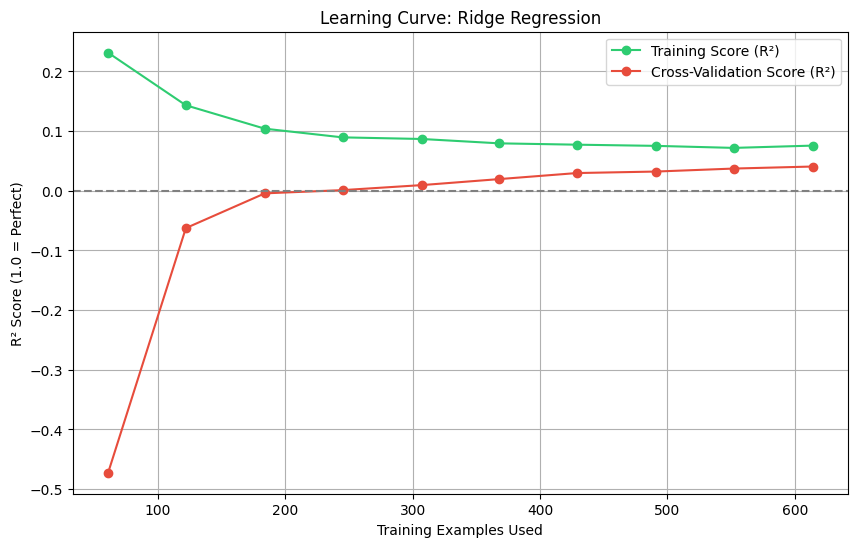

In [7]:
# ==============================================================================
# HELPER: REGRESSION EVALUATION
# ==============================================================================
def evaluate_regression(y_true, y_pred, model_name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} PERFORMANCE ---")
    print(f"   RMSE (Lower is better): {rmse:.4f}")
    print(f"   MAE  (Lower is better): {mae:.4f}")
    print(f"   R²   (Higher is better): {r2:.4f}")
    print(f"   (R²=0.0 means the model is just guessing the average)")

# ---------------------------------------------------------
# STEP 5 (Part A): ESTABLISH THE DUMMY BASELINE
# ---------------------------------------------------------
# Why: If our complex model can't beat this, it's useless.
# This "stupid" model just guesses the MEAN success score every time.

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

evaluate_regression(y_test, y_pred_dummy, "BASELINE (DUMMY)")
print("\n")

# ---------------------------------------------------------
# STEP 4 & 5 (Part B): TRAIN RIDGE REGRESSION
# ---------------------------------------------------------
# We use Ridge (Linear Regression + L2 Regularization) 
# because it handles small datasets (N=961) better than simple LinearRegression.

model = Ridge(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

# Predictions (Continuous Float values)
y_pred = model.predict(X_test)

evaluate_regression(y_test, y_pred, "RIDGE REGRESSION")

# ---------------------------------------------------------
# VISUALIZATION: LEARNING CURVE
# ---------------------------------------------------------
# This answers: "Is my model learning? Would more data help?"
# We use 'r2' (Coefficient of Determination) as the score.

train_sizes, train_scores, test_scores = learning_curve(
    model, X_train, y_train, cv=5, scoring='r2',
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate means for plotting
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="#2ecc71", label="Training Score (R²)")
plt.plot(train_sizes, test_mean, 'o-', color="#e74c3c", label="Cross-Validation Score (R²)")

plt.title("Learning Curve: Ridge Regression")
plt.xlabel("Training Examples Used")
plt.ylabel("R² Score (1.0 = Perfect)")
plt.legend(loc="best")
plt.grid(True)
plt.axhline(y=0, color='gray', linestyle='--', label='Baseline (Mean)')
plt.show()

**Conclusion:**

- Model is too simple. It cannot capture the pattern even in the training data (Green line dropped essentially to random chance).
- Model is technically "worse" than doing nothing. This happens because class_weight='balanced' forces the model to guess "Success" more often. Since the model isn't smart yet, it makes many False Positives, dragging the score down.

## Random Forest

⏳ Training Random Forest...
--- RANDOM FOREST PERFORMANCE ---
   RMSE (Lower is better): 0.2090
   MAE  (Lower is better): 0.1692
   R²   (Higher is better): 0.0492
   (R²=0.0 means the model is just guessing the average)


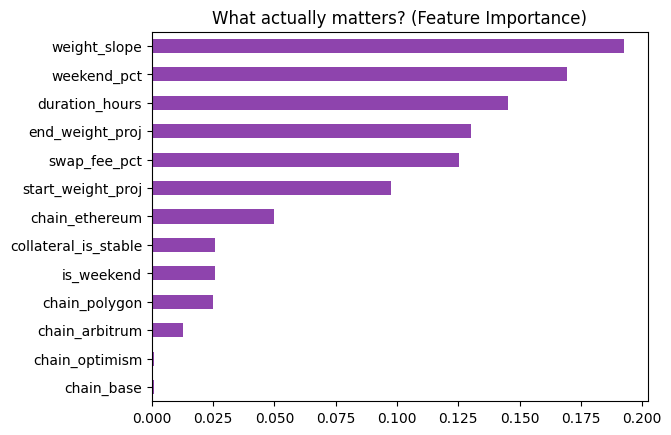

In [9]:
print("⏳ Training Random Forest...")

rf_model = RandomForestRegressor(
    n_estimators=200,      # Number of trees
    max_depth=10,          # Prevent overfitting
    min_samples_split=5,   # Regularization
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

evaluate_regression(y_test, y_pred_rf, "RANDOM FOREST")

# ---------------------------------------------------------
# FEATURE IMPORTANCE (The Truth Serum)
# ---------------------------------------------------------
# If RF fails too, then the data truly has no signal.
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=True).plot(kind='barh', color='#8e44ad')
plt.title("What actually matters? (Feature Importance)")
plt.show()

## XGBoost

⏳ Starting Randomized Hyperparameter Search (This may take a minute)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Best Params Found: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

--- XGBOOST FINAL RESULTS ---
   RMSE (Lower is better): 0.2083
   MAE  (Lower is better): 0.1716
   R²   (Higher is better): 0.0558


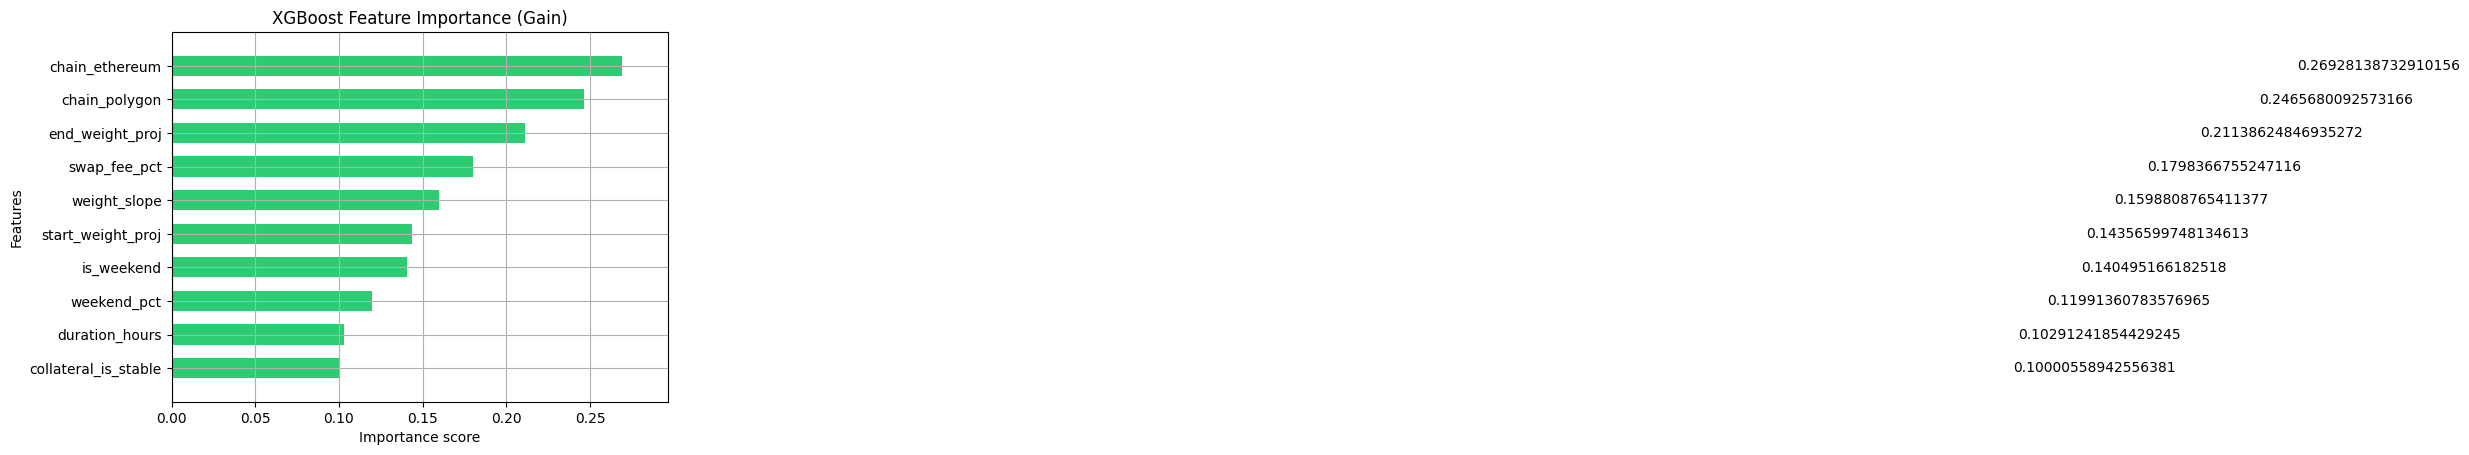

In [35]:
def train_xgboost():
    
    # ==========================================================================
    # 1. DEFINE HYPERPARAMETER GRID
    # ==========================================================================
    # XGBoost needs tuning. We test random combinations of these settings.
    param_grid = {
        'n_estimators': [100, 300, 500],        # Number of boosting rounds
        'learning_rate': [0.01, 0.05, 0.1],     # How much each tree corrects errors
        'max_depth': [3, 5, 7],                 # Tree depth (prevent overfitting)
        'subsample': [0.7, 0.8, 0.9],           # Use only % of rows per tree
        'colsample_bytree': [0.7, 0.8, 1.0],    # Use only % of columns per tree
        'reg_alpha': [0, 0.1, 0.5],             # L1 Regularization
        'reg_lambda': [1, 1.5, 2]               # L2 Regularization
    }
    
    print("⏳ Starting Randomized Hyperparameter Search (This may take a minute)...")
    
    xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)
    
    # Try 50 random combinations
    search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=param_grid,
        n_iter=50,
        scoring='r2',
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )
    
    search.fit(X_train, y_train)
    
    # ==========================================================================
    # 2. EVALUATE BEST MODEL
    # ==========================================================================
    best_model = search.best_estimator_
    print(f"\n✅ Best Params Found: {search.best_params_}")
    
    y_pred = best_model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print("\n--- XGBOOST FINAL RESULTS ---")
    print(f"   RMSE (Lower is better): {rmse:.4f}")
    print(f"   MAE  (Lower is better): {mae:.4f}")
    print(f"   R²   (Higher is better): {r2:.4f}")

    # ==========================================================================
    # 3. FEATURE IMPORTANCE PLOT
    # ==========================================================================
    # XGBoost calculates importance differently (Gain = Improvement in accuracy)
    xgb.plot_importance(best_model, importance_type='gain', max_num_features=10, height=0.6, color='#2ecc71')
    plt.title('XGBoost Feature Importance (Gain)')
    plt.show()

if __name__ == "__main__":
    train_xgboost()

## Multi-target prediction 

## Random Forest

📂 Loading datasets...
   Merged Data Shape: (960, 25)
🚀 Starting Multi-Target Prediction Experiment...
   Features used: ['duration_hours', 'start_weight_proj', 'end_weight_proj', 'weight_slope', 'swap_fee_pct', 'collateral_is_stable', 'is_weekend', 'weekend_pct', 'chain_arbitrum', 'chain_base', 'chain_ethereum', 'chain_optimism', 'chain_polygon']
   🎯 Predicting 'volume_usd': R² = -0.1055
   🎯 Predicting 'unique_buyers': R² = 0.0767
   🎯 Predicting 'price_retention': R² = -5.2389
   🎯 Predicting 'volatility_score': R² = -0.1307
   🎯 Predicting 'bot_tx_ratio': R² = -0.1169
   🎯 Predicting 'dump_pressure': R² = -17565001146391.9355
   🎯 Predicting 'volume_time_skew': R² = 0.0266
   🎯 Predicting 'whale_dominance_pct': R² = -0.0018
   🎯 Predicting 'turnover_ratio': R² = -0.0932
   🎯 Predicting 'bot_extraction_usd': R² = 0.0047
   🎯 Predicting 'price_discovery_stability': R² = -0.2419


C:\Users\kaiqu\AppData\Local\Temp\ipykernel_19376\1307620281.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='R2_Score', y='Metric', palette=colors)


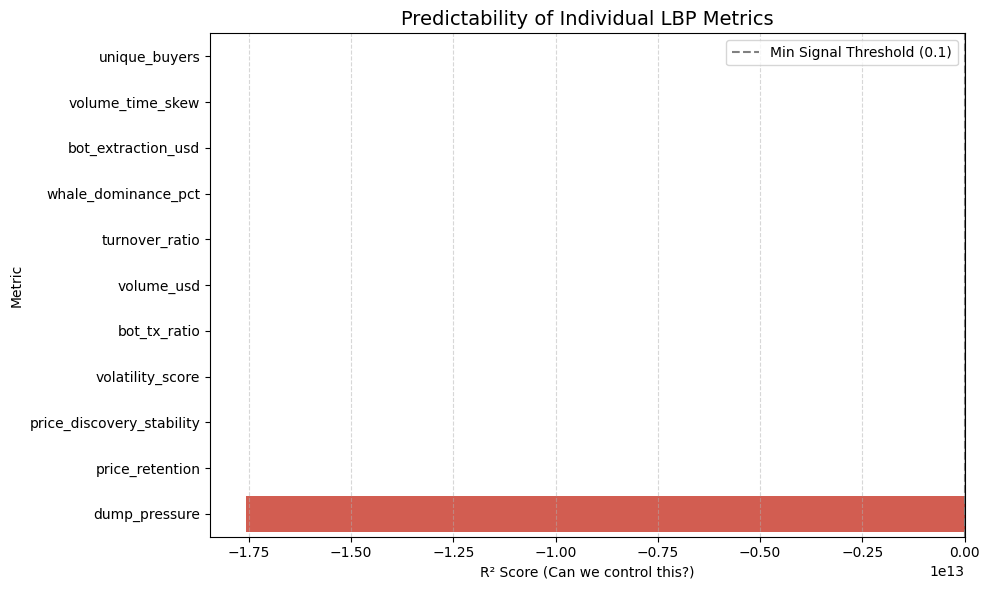

In [24]:
# ==============================================================================
# CONFIGURATION
# ==============================================================================
FILE_FEATURES = "../media/dune_api_downloads/table_a_final_enriched.csv"  # Source of Table A (Inputs)
FILE_TARGETS = "../media/dune_api_downloads/improved_table_b_advanced.csv"   # Source of Table B (Outputs)

def load_and_merge_data():
    print("📂 Loading datasets...")
    
    # 1. Load Data
    try:
        df_x = pd.read_csv(FILE_FEATURES)
        df_y = pd.read_csv(FILE_TARGETS)
    except FileNotFoundError as e:
        print(f"❌ Error: {e}")
        return None, None

    # 2. Merge on 'pool_address'
    # We use inner join to ensure we only analyze pools that exist in BOTH files
    full_df = pd.merge(df_x, df_y, on='pool_address', how='inner', suffixes=('', '_dup'))
    
    # Remove any duplicate columns created by the merge (e.g., if 'final_success_score' is in both)
    full_df = full_df.loc[:, ~full_df.columns.str.endswith('_dup')]
    
    print(f"   Merged Data Shape: {full_df.shape}")

    # 3. Define Features (X)
    # We keep only the configuration columns from Table A
    # We must DROP the result columns (Table B) and IDs
    
    # List of known Table B columns (The Targets)
    target_cols = [
        'volume_usd', 'unique_buyers', 'price_retention', 
        'volatility_score', 'bot_tx_ratio', 'dump_pressure', 
        'final_success_score', 'volume_time_skew', 'whale_dominance_pct',
        'turnover_ratio', 'bot_extraction_usd', 'price_discovery_stability'
    ]
    
    # List of ID/Metadata columns to drop
    meta_cols = ['pool_address', 'start_weight_reserve', 'end_weight_reserve', 'start_timestamp', 'version', ]
    
    # Drop everything that is NOT a feature
    cols_to_drop = [c for c in target_cols + meta_cols if c in full_df.columns]
    X = full_df.drop(columns=cols_to_drop)
    
    # Standard Cleaning for X
    if 'duration_hours' in X.columns:
        X['duration_hours'] = np.clip(X['duration_hours'], 12, 168)
    X = pd.get_dummies(X, columns=['chain'], prefix='chain', dtype=int)
    
    return full_df, X, target_cols

def run_multi_target_experiment():
    full_df, X, all_potential_targets = load_and_merge_data()
    if full_df is None: return

    print(f"🚀 Starting Multi-Target Prediction Experiment...")
    print(f"   Features used: {list(X.columns)}")
    
    results = []
    
    # 4. Loop through each target individually
    # We skip 'final_success_score' because we already know it failed.
    # We focus on the COMPONENTS.
    targets_to_test = [t for t in all_potential_targets if t != 'final_success_score']
    
    for target in targets_to_test:
        if target not in full_df.columns:
            continue
            
        y = full_df[target]
        
        # Handle NaN in targets (e.g., if volatility is NaN for single-trade pools)
        if y.isna().sum() > 0:
            valid_idx = y.dropna().index
            X_curr = X.loc[valid_idx]
            y_curr = y.loc[valid_idx]
        else:
            X_curr, y_curr = X, y

        # Split
        X_train, X_test, y_train, y_test = train_test_split(X_curr, y_curr, test_size=0.2, random_state=42)
        
        # Train RF
        model = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        
        # Evaluate
        y_pred = model.predict(X_test)
        score = r2_score(y_test, y_pred)
        
        print(f"   🎯 Predicting '{target}': R² = {score:.4f}")
        results.append({'Metric': target, 'R2_Score': score})

    # 5. Visualize Results
    if not results: return

    results_df = pd.DataFrame(results).sort_values(by='R2_Score', ascending=False)
    
    plt.figure(figsize=(10, 6))
    
    # Color logic: Green if we found a signal (>0.1), Red if noise
    colors = ['#2ecc71' if x > 0.10 else '#e74c3c' for x in results_df['R2_Score']]
    
    sns.barplot(data=results_df, x='R2_Score', y='Metric', palette=colors)
    
    plt.axvline(0, color='black', linewidth=1)
    plt.axvline(0.10, color='gray', linestyle='--', label='Min Signal Threshold (0.1)')
    plt.title('Predictability of Individual LBP Metrics', fontsize=14)
    plt.xlabel('R² Score (Can we control this?)')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_multi_target_experiment()

📂 Loading datasets...
   Merged Shape: (960, 25)

🛡️ STARTING RISK CLASSIFICATION...
   Features used: ['duration_hours', 'start_weight_proj', 'end_weight_proj', 'weight_slope', 'swap_fee_pct', 'collateral_is_stable', 'is_weekend', 'weekend_pct', 'chain_arbitrum', 'chain_base', 'chain_ethereum', 'chain_optimism', 'chain_polygon']
   🎯 Target: High dump_pressure (>2.0) | Accuracy: 78.6% | AUC: 0.759
   🎯 Target: High bot_tx_ratio (>0.1)  | Accuracy: 81.8% | AUC: 0.616
   🎯 Target: High volatility_score (>1.5) | Accuracy: 84.9% | AUC: 0.603
   🎯 Target: Crash (<0.5)              | Accuracy: 65.1% | AUC: 0.633
   🎯 Target: High whale_dominance_pct (>0.5) | Accuracy: 86.5% | AUC: 0.614


C:\Users\kaiqu\AppData\Local\Temp\ipykernel_16400\1037702688.py:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res_df, x='AUC', y='Label', palette=colors)


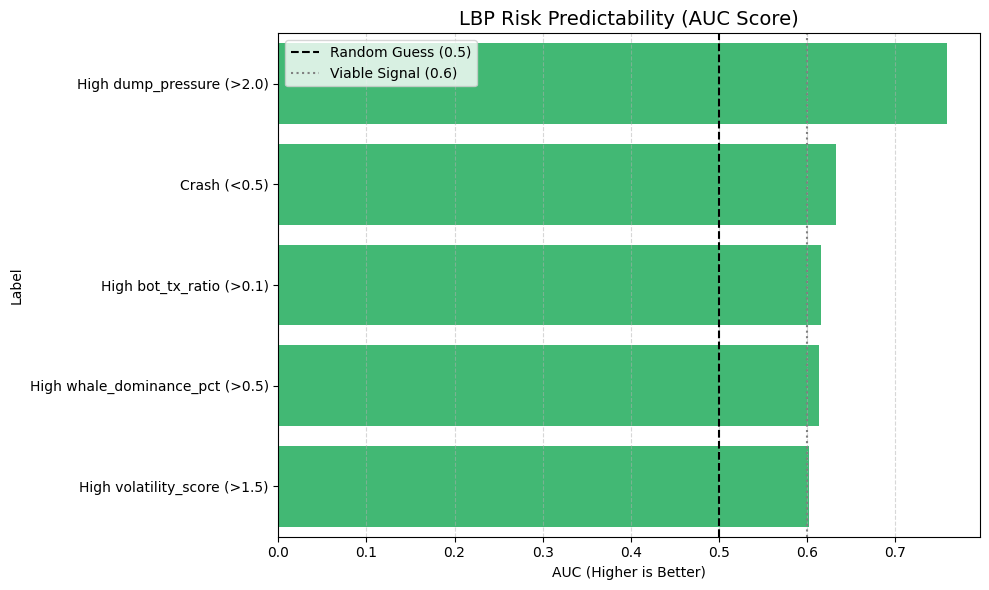

In [4]:
# ==============================================================================
# CONFIGURATION
# ==============================================================================
FILE_A = "../media/dune_api_downloads/table_a_final_enriched.csv"  # Source of Table A (Inputs)
FILE_B = "../media/dune_api_downloads/improved_table_b_advanced.csv"   # Source of Table B (Outputs)

# DEFINING "FAILURE": The Thresholds
# If a pool crosses these lines, we classify it as "High Risk" (Class 1)
RISK_THRESHOLDS = {
    # 1. DUMP RISK: Selling pressure is > 2x Buying pressure
    'dump_pressure': 2.0,       
    
    # 2. BOT RISK: More than 10% of early transactions are bots
    'bot_tx_ratio': 0.10,       
    
    # 3. VOLATILITY RISK: Extreme price swings relative to mean
    'volatility_score': 1.5,    
    
    # 4. CRASH RISK: Price drops > 50% from start (Retention < 0.5)
    'price_retention': 0.5,     
    
    # 5. WHALE RISK: Top 1% of traders control > 50% of volume
    'whale_dominance_pct': 0.50 
}

def load_and_prep_data():
    print("📂 Loading datasets...")
    try:
        df_a = pd.read_csv(FILE_A)
        df_b = pd.read_csv(FILE_B)
        
        # Merge on pool_address
        df = pd.merge(df_a, df_b, on='pool_address', how='inner')
        print(f"   Merged Shape: {df.shape}")
    except FileNotFoundError as e:
        print(f"❌ Error: {e}")
        return None, None

    # ---------------------------------------------------------
    # 1. CLEANING & CLIPPING (Fixing the "Infinity Bug")
    # ---------------------------------------------------------
    # Cap extreme outliers to prevent model confusion before bucketing
    df['dump_pressure'] = df['dump_pressure'].clip(upper=10.0)
    df['volatility_score'] = df['volatility_score'].clip(upper=5.0)
    if 'duration_hours' in df.columns:
        df['duration_hours'] = np.clip(df['duration_hours'], 12, 168)

    # ---------------------------------------------------------
    # 2. FEATURE SELECTION (Table A only)
    # ---------------------------------------------------------
    # We drop ID cols, Timestamp cols, and Reserve weights (redundant with Proj weights)
    cols_to_drop = [
        'pool_address', 'version', 'start_timestamp', 
        'start_weight_reserve', 'end_weight_reserve'
    ]
    # Also drop the Targets (Table B columns) to prevent data leakage
    targets_in_b = [
        'volume_usd', 'unique_buyers', 'price_retention', 'volatility_score',
        'dump_pressure', 'volume_time_skew', 'whale_dominance_pct',
        'turnover_ratio', 'bot_tx_ratio', 'bot_extraction_usd', 
        'price_discovery_stability'
    ]
    
    # Define X (Features)
    feature_cols = [c for c in df_a.columns if c not in cols_to_drop]
    X = df[feature_cols].copy()
    
    # One-Hot Encode Chain (Categorical -> Numerical)
    X = pd.get_dummies(X, columns=['chain'], prefix='chain', dtype=int)
    
    return df, X

def run_risk_experiment():
    full_df, X = load_and_prep_data()
    if full_df is None: return

    print("\n🛡️ STARTING RISK CLASSIFICATION...")
    print(f"   Features used: {list(X.columns)}")
    print("="*65)
    
    results = []

    # Loop through each Risk Type independently
    for metric, threshold in RISK_THRESHOLDS.items():
        if metric not in full_df.columns: 
            print(f"⚠️ Warning: Metric '{metric}' not found in data.")
            continue
            
        # -----------------------------------------------------
        # 3. DEFINE TARGET (Y)
        # -----------------------------------------------------
        # Logic: 1 = BAD (Risk), 0 = GOOD (Safe)
        
        if metric == 'price_retention':
            # Special Case: LOW retention is bad
            y = (full_df[metric] < threshold).astype(int)
            risk_label = f"Crash (<{threshold})"
        else:
            # Standard Case: HIGH value is bad
            y = (full_df[metric] > threshold).astype(int)
            risk_label = f"High {metric} (>{threshold})"
            
        # Check Class Balance (If 99% are High Risk, accuracy is misleading)
        risk_rate = y.mean()
        if risk_rate < 0.05 or risk_rate > 0.95:
            print(f"   ⏭️  Skipping {risk_label}: Imbalanced ({risk_rate:.1%} risky). Model won't learn.")
            continue

        # -----------------------------------------------------
        # 4. TRAIN MODEL
        # -----------------------------------------------------
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # We use Random Forest Classifier (Robust to noise)
        clf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
        clf.fit(X_train, y_train)
        
        # -----------------------------------------------------
        # 5. EVALUATE
        # -----------------------------------------------------
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:, 1]
        
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        
        print(f"   🎯 Target: {risk_label:<25} | Accuracy: {acc:.1%} | AUC: {auc:.3f}")
        
        results.append({
            'Risk_Metric': metric,
            'Label': risk_label,
            'Accuracy': acc,
            'AUC': auc,
            'Model': clf # Save model for feature importance later if needed
        })

    # ---------------------------------------------------------
    # 6. VISUALIZE RESULTS
    # ---------------------------------------------------------
    if not results: return

    res_df = pd.DataFrame(results).sort_values(by='AUC', ascending=False)
    
    plt.figure(figsize=(10, 6))
    
    # Color Logic: Green if AUC > 0.6 (Predictable), Red if < 0.6 (Random)
    colors = ['#2ecc71' if x >= 0.60 else '#e74c3c' for x in res_df['AUC']]
    
    sns.barplot(data=res_df, x='AUC', y='Label', palette=colors)
    plt.axvline(0.5, color='black', linestyle='--', label='Random Guess (0.5)')
    plt.axvline(0.6, color='gray', linestyle=':', label='Viable Signal (0.6)')
    
    plt.title('LBP Risk Predictability (AUC Score)', fontsize=14)
    plt.xlabel('AUC (Higher is Better)')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_risk_experiment()

## XGBoost

🛠️ Loading & Engineering Features...

🚀 STARTING XGBOOST CLASSIFICATION (V2)
   New Features: slope_per_hour, weight_delta, confidence_score
RISK METRIC               | ACCURACY   | AUC SCORE  | STATUS
---------------------------------------------------------------------------
High dump_pressure (>2.0) | 75.5%     | 0.717      | ✅ STRONG
High bot_tx_ratio (>0.1)  | 76.6%     | 0.632      | ⚠️ VIABLE
High volatility_score (>1.5) | 83.9%     | 0.553      | ❌ NOISE
Low price_retention (<0.5) | 62.5%     | 0.597      | ❌ NOISE
Low turnover_ratio (<5.0) | 84.9%     | 0.752      | ✅ STRONG
High volume_time_skew (>0.6) | 82.3%     | 0.671      | ⚠️ VIABLE
High price_discovery_stability (>0.5) | 87.5%     | 0.641      | ⚠️ VIABLE


C:\Users\kaiqu\AppData\Local\Temp\ipykernel_16400\235557662.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res_df, x='AUC', y='Metric', palette=colors)


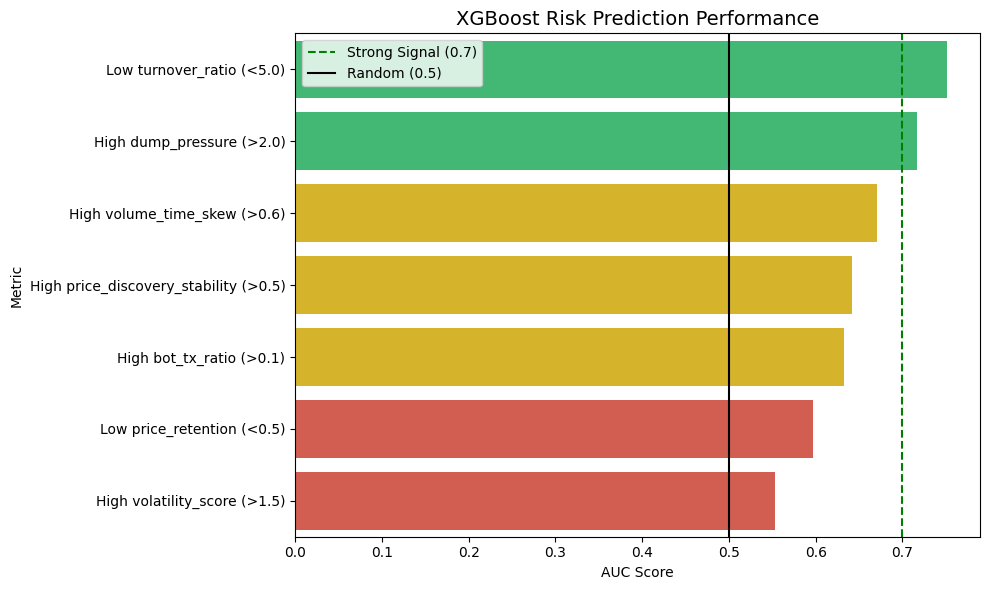

In [ ]:
# 1. NEW TARGETS ADDED
RISK_THRESHOLDS = {
    # --- PROVEN SIGNAL (Keep optimizing) ---
    'dump_pressure': 2.0,       # > 2.0 = High Sell Pressure
    
    # --- IMPROVEMENT CANDIDATES (Trying XGBoost) ---
    'bot_tx_ratio': 0.10,       # > 10% Bots
    'volatility_score': 1.5,    # > 1.5 High Volatility
    'price_retention': 0.5,     # < 50% Crash Risk (Logic inverted in loop)
    
    # --- NEW UNTESTED METRICS ---
    'turnover_ratio': 5.0,      # < 5.0 = Low Capital Efficiency (Bad)
    'volume_time_skew': 0.6,    # > 0.6 = Back-Loaded (Panic Selling Risk)
    'price_discovery_stability':0.5 # > 0.5 = Unstable Settlement
}

def load_and_engineer_features():
    print("🛠️ Loading & Engineering Features...")
    try:
        df_a = pd.read_csv(FILE_A)
        df_b = pd.read_csv(FILE_B)
        df = pd.merge(df_a, df_b, on='pool_address', how='inner')
    except Exception as e:
        print(f"❌ Error: {e}")
        return None, None

    # 1. Standard Cleaning
    df['dump_pressure'] = df['dump_pressure'].clip(upper=10.0)
    df['volatility_score'] = df['volatility_score'].clip(upper=5.0)
    if 'duration_hours' in df.columns:
        df['duration_hours'] = np.clip(df['duration_hours'], 12, 168)

    # 2. 🧠 FEATURE ENGINEERING (The Upgrade)
    # Ratios often matter more than raw numbers
    
    # A. Slope Density: Is the slope steep relative to the time?
    df['slope_per_hour'] = df['weight_slope'] / df['duration_hours']
    
    # B. Weight Spread: Total weight change
    df['weight_delta'] = (df['start_weight_proj'] - df['end_weight_proj']).abs()
    
    # C. Project Viability Proxy: High fee + Long Duration = Confident Team?
    df['confidence_score'] = df['swap_fee_pct'] * df['duration_hours']

    # 3. Define X (Features)
    # Drop all Targets/Leakage
    drop_cols = list(df_b.columns) + [
        'version', 'start_timestamp', 'start_weight_reserve', 'end_weight_reserve',
        'slope_per_hour', 'weight_delta', 'confidence_score' # Don't drop new features
    ]
    
    # Keep only known inputs + new features
    input_cols = [c for c in df_a.columns if c not in ['pool_address', 'version', 'start_timestamp', 'start_weight_reserve', 'end_weight_reserve']]
    input_cols += ['slope_per_hour', 'weight_delta', 'confidence_score']
    
    X = df[input_cols].copy()
    X = pd.get_dummies(X, columns=['chain'], prefix='chain', dtype=int)
    
    return df, X

def run_xgboost_experiment():
    full_df, X = load_and_engineer_features()
    if full_df is None: return

    print(f"\n🚀 STARTING XGBOOST CLASSIFICATION (V2)")
    print(f"   New Features: slope_per_hour, weight_delta, confidence_score")
    print("="*75)
    print(f"{'RISK METRIC':<25} | {'ACCURACY':<10} | {'AUC SCORE':<10} | {'STATUS'}")
    print("-" * 75)
    
    results = []

    for metric, threshold in RISK_THRESHOLDS.items():
        if metric not in full_df.columns: continue

        # Define Target (Handle Inversions)
        if metric in ['price_retention', 'turnover_ratio']:
            # For these, LOW is bad.
            y = (full_df[metric] < threshold).astype(int)
            label = f"Low {metric} (<{threshold})"
        else:
            # For others, HIGH is bad.
            y = (full_df[metric] > threshold).astype(int)
            label = f"High {metric} (>{threshold})"

        # Check Balance
        if y.mean() < 0.05 or y.mean() > 0.95:
            print(f"{label:<25} | {'SKIP':<10} | {'---':<10} | ⚠️ Imbalanced")
            continue

        # Train XGBoost
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        model = xgb.XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            eval_metric=roc_auc_score
        )
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        
        # Status Flag
        if auc >= 0.70: status = "✅ STRONG"
        elif auc >= 0.60: status = "⚠️ VIABLE"
        else: status = "❌ NOISE"
        
        print(f"{label:<25} | {acc:.1%}     | {auc:.3f}      | {status}")
        results.append({'Metric': label, 'AUC': auc})

    # Visualization
    if results:
        res_df = pd.DataFrame(results).sort_values(by='AUC', ascending=False)
        plt.figure(figsize=(10, 6))
        colors = ['#2ecc71' if x >= 0.7 else '#f1c40f' if x >= 0.6 else '#e74c3c' for x in res_df['AUC']]
        sns.barplot(data=res_df, x='AUC', y='Metric', palette=colors)
        plt.axvline(0.7, color='green', linestyle='--', label='Strong Signal (0.7)')
        plt.axvline(0.5, color='black', linestyle='-', label='Random (0.5)')
        plt.title('XGBoost Risk Prediction Performance', fontsize=14)
        plt.xlabel('AUC Score')
        plt.legend()
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    run_xgboost_experiment()

🔬 Generating Refined Optimization Curves...
   ... Plotting DUMP RISK
(Prob. of High Sell Pressure) (Avg Risk: 31.8%) ...
   ... Plotting INEFFICIENCY RISK
(Prob. of Low Volume/Liq) (Avg Risk: 86.1%) ...


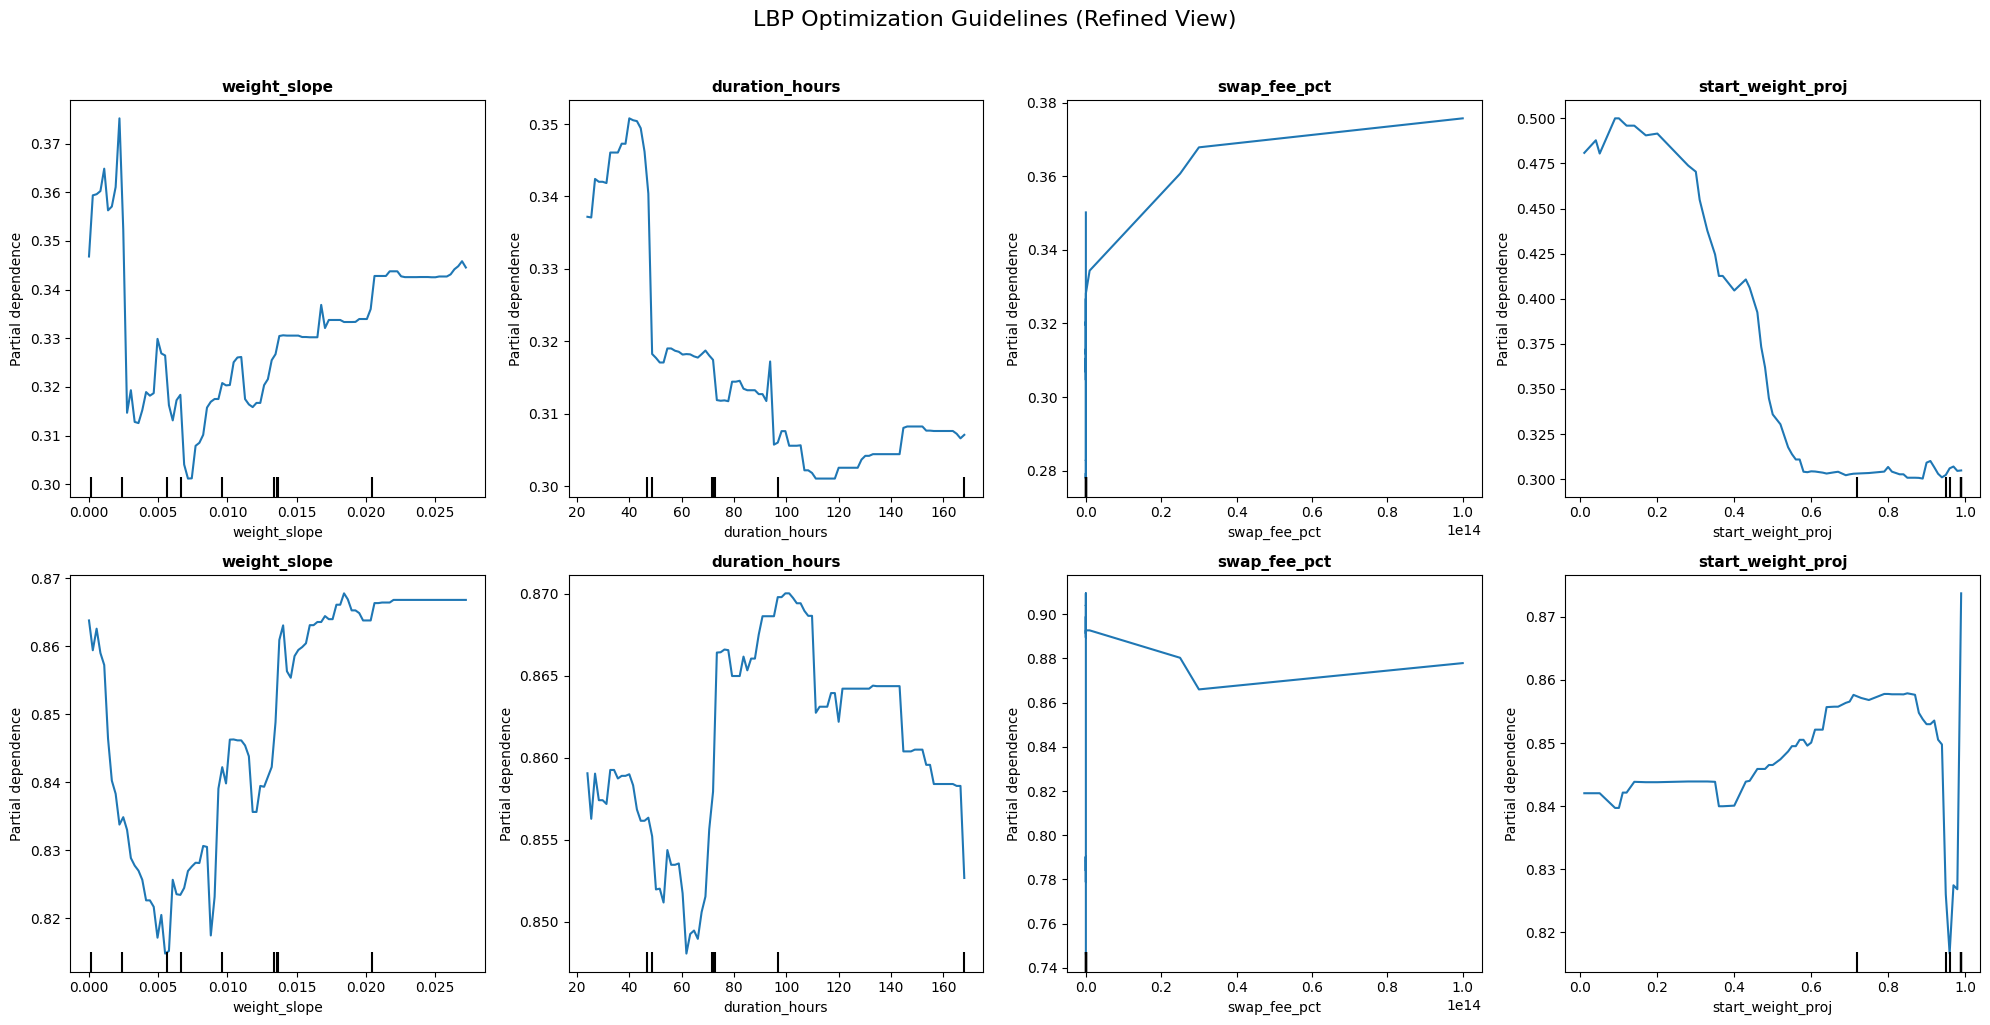

In [16]:
# The Metrics we successfully predicted (AUC > 0.70)
WINNERS = {
    'dump_pressure': {
        'threshold': 2.0, 
        'label': 'DUMP RISK\n(Prob. of High Sell Pressure)', 
        'bad_direction': 'high',
        'color': '#e74c3c' # Red
    },
    'turnover_ratio': {
        'threshold': 5.0, 
        'label': 'INEFFICIENCY RISK\n(Prob. of Low Volume/Liq)', 
        'bad_direction': 'low',
        'color': '#f39c12' # Orange
    }
}

# The Levers we want to optimize
FEATURES = ['weight_slope', 'duration_hours', 'swap_fee_pct', 'start_weight_proj']

def load_data():
    try:
        df_a = pd.read_csv(FILE_A)
        df_b = pd.read_csv(FILE_B)
        df = pd.merge(df_a, df_b, on='pool_address', how='inner')
    except Exception as e:
        print(f"❌ Error loading files: {e}")
        return None, None
    
    # Clean Outliers in Targets (Safety Clip)
    df['dump_pressure'] = df['dump_pressure'].clip(upper=10.0)
    
    # Prepare X (Features)
    cols_to_drop = list(df_b.columns) + ['pool_address', 'version', 'start_timestamp', 'start_weight_reserve', 'end_weight_reserve']
    X = df[[c for c in df_a.columns if c not in cols_to_drop]].copy()
    X = pd.get_dummies(X, columns=['chain'], prefix='chain', dtype=int)
    
    return df, X

def plot_refined_curves():
    print("🔬 Generating Refined Optimization Curves...")
    full_df, X = load_data()
    if full_df is None: return

    # Setup Plot Grid
    fig, axes = plt.subplots(len(WINNERS), len(FEATURES), figsize=(20, 10))
    
    for i, (metric, settings) in enumerate(WINNERS.items()):
        # 1. Define Target (1 = BAD/RISK, 0 = GOOD)
        if settings['bad_direction'] == 'low':
            y = (full_df[metric] < settings['threshold']).astype(int)
        else:
            y = (full_df[metric] > settings['threshold']).astype(int)

        # 2. Train Model (Random Forest - The one that worked)
        model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
        model.fit(X, y)
        
        avg_risk = y.mean()
        print(f"   ... Plotting {settings['label']} (Avg Risk: {avg_risk:.1%}) ...")

        # 3. Plot Each Feature
        for j, feature in enumerate(FEATURES):
            if feature not in X.columns: continue
            
            ax = axes[i, j]
            
            # --- THE FIX: Focus on the 5th-95th Percentile ---
            # This ignores outliers that "squish" the graph
            quantiles = X[feature].quantile([0.05, 0.95]).values
            
            PartialDependenceDisplay.from_estimator(
                model, X, [feature],
                ax=ax,
                kind='average',
                percentiles=(0.05, 0.95), # <--- Zooms in on real data
                # line_kws={'color': '#e74c3c', 'linewidth': 2.5}
            )
            
            # Formatting
            ax.set_title(f"{feature}", fontsize=11, fontweight='bold')
            ax.set_ylabel("Risk Probability")
            ax.grid(True, linestyle='--', alpha=0.5)
            
            # Add "Safe Zone" Reference Line
            ax.axhline(avg_risk, color='gray', linestyle=':', label='Avg Risk')
            
            # Add "Rug Plot" (Little ticks on bottom showing where data points are)
            # This helps you see if a spike is based on 1 pool or 100 pools
            ax.plot(X[feature], np.full(len(X), -0.05), '|', color='k', alpha=0.1)

            # Row Label
            if j == 0:
                ax.set_ylabel(f"{settings['label']}\n(Probability)", fontsize=12, fontweight='bold')

    plt.suptitle("LBP Optimization Guidelines (Refined View)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_refined_curves()

# Moving from prediction to optimization

🔄 Retraining RF on Unscaled Data for Interpretability...
📊 Generating Sweet Spot Analysis...


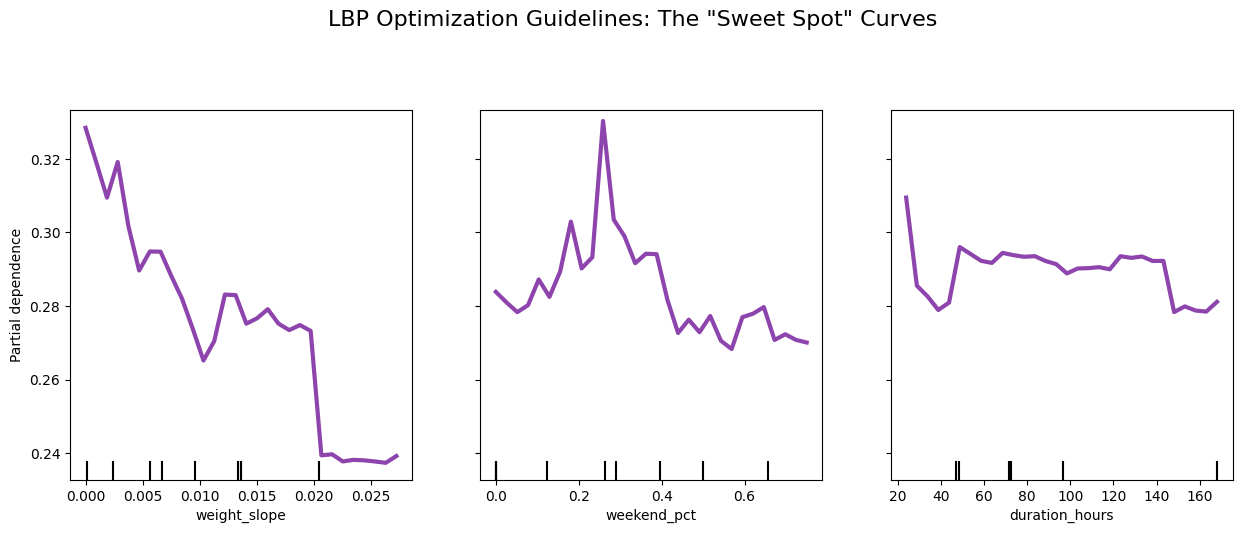

In [ ]:
INPUT_FILE = "../media/ML/training_dataset.csv"  # The raw merged file (Unscaled)

# ==============================================================================
# 1. PREPARE DATA (UNSCALED)
# ==============================================================================
def load_unscaled_data():
    df = pd.read_csv(INPUT_FILE)
    
    # Drop redundant columns (Reserve weights)
    cols_to_drop = ['start_weight_reserve', 'end_weight_reserve', 'pool_address']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    # Cap outliers (just to keep graphs clean)
    # We clip Duration at 168h (1 week) because rarely LBPs go longer
    if 'duration_hours' in df.columns:
        df['duration_hours'] = np.clip(df['duration_hours'], 12, 168)
        
    # One-Hot Encode Chain
    df = pd.get_dummies(df, columns=['chain'], prefix='chain', dtype=int)
    
    # Split X and y
    target_col = 'final_success_score'
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    return X, y

# ==============================================================================
# 2. GENERATE PARTIAL DEPENDENCE PLOTS
# ==============================================================================
def plot_sweet_spots():
    print("🔄 Retraining RF on Unscaled Data for Interpretability...")
    X, y = load_unscaled_data()
    
    # Train RF (Same parameters as before)
    model = RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_split=5, 
        random_state=42, n_jobs=-1
    )
    model.fit(X, y)
    
    print("📊 Generating Sweet Spot Analysis...")
    
    # Features to Analyze (The Top 3 from your Importance Plot)
    features_to_plot = [
        'weight_slope',  # Velocity
        'weekend_pct',   # Timing
        'duration_hours' # Time Window
    ]
    
    # Create the Plot
    fig, ax = plt.subplots(figsize=(15, 5))
    display = PartialDependenceDisplay.from_estimator(
        model, 
        X, 
        features_to_plot,
        kind="average", # Shows the trend
        n_jobs=-1, 
        grid_resolution=30,
        ax=ax,
        line_kw={"color": "#8e44ad", "linewidth": 3}
    )
    
    # Formatting
    fig.suptitle('LBP Optimization Guidelines: The "Sweet Spot" Curves', fontsize=16, y=1.05)
    plt.subplots_adjust(top=0.85)
    plt.show()

if __name__ == "__main__":
    plot_sweet_spots()

## Stability test

🔄 Training 20 Bootstrap Models & Computing Curves...


/home/kaique/Documents/Projetos/fair-launch-analytics/venv/lib64/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 'is_weekend' contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/home/kaique/Documents/Projetos/fair-launch-analytics/venv/lib64/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 'chain_arbitrum' contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-

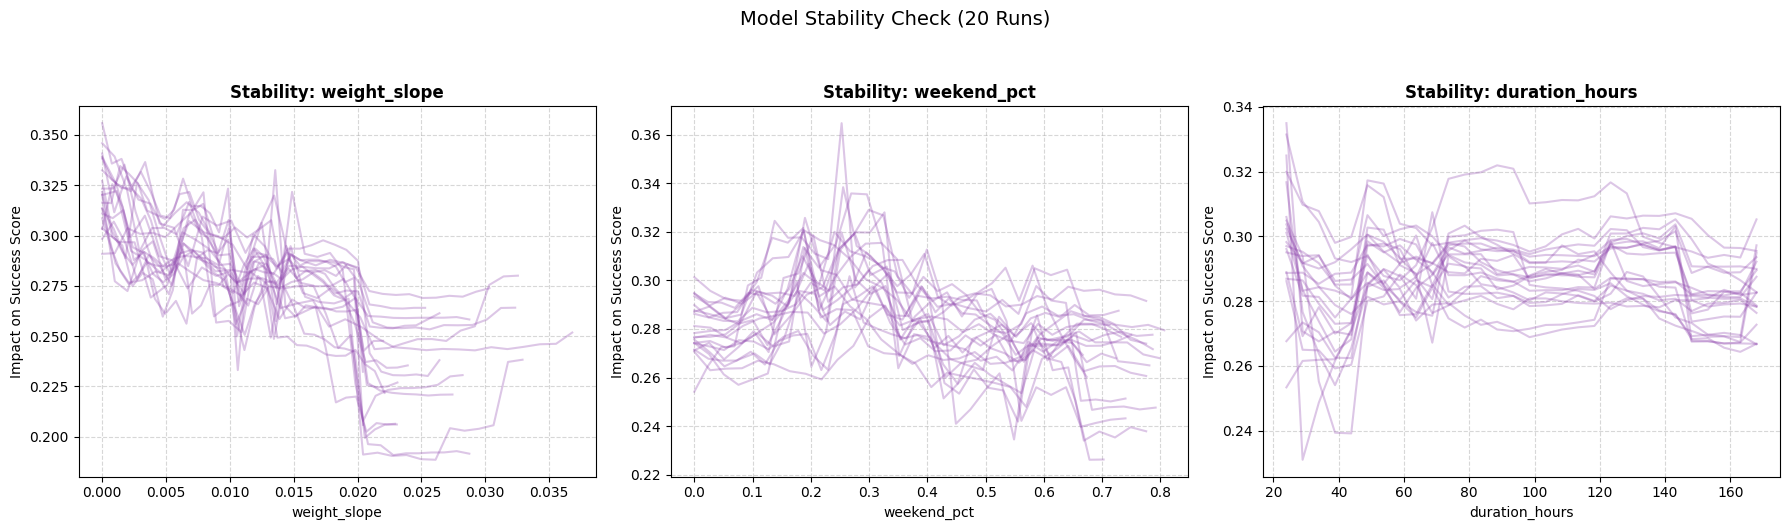


FEATURE                   | IMPACT     | NOISE      | STABILITY 
chain_ethereum            | 0.0701     | 0.0139     | 80.1% ⭐
weight_slope              | 0.0835     | 0.0200     | 76.0% ⭐
swap_fee_pct              | 0.0518     | 0.0176     | 65.9% 
end_weight_proj           | 0.0433     | 0.0153     | 64.7% 
weekend_pct               | 0.0397     | 0.0144     | 63.8% 
duration_hours            | 0.0261     | 0.0108     | 58.9% 
start_weight_proj         | 0.0316     | 0.0152     | 51.8% 
chain_polygon             | 0.0256     | 0.0138     | 46.0% 
is_weekend                | 0.0123     | 0.0086     | 30.5% 
collateral_is_stable      | 0.0033     | 0.0078     | 0.0% 
chain_arbitrum            | 0.0001     | 0.0070     | 0.0% 
chain_base                | 0.0016     | 0.0068     | 0.0% 
chain_optimism            | 0.0004     | 0.0070     | 0.0% 
⭐ = Prime Candidate for Optimization Guidelines


In [ ]:
N_BOOTSTRAPS = 20
FEATURES_TO_PLOT = ['weight_slope', 'weekend_pct', 'duration_hours']

def load_data():
    df = pd.read_csv(INPUT_FILE)
    
    # Standard Cleaning
    cols_to_drop = ['start_weight_reserve', 'end_weight_reserve', 'pool_address']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    if 'duration_hours' in df.columns:
        df['duration_hours'] = np.clip(df['duration_hours'], 12, 168)
        
    # One-Hot Encode Chain
    df = pd.get_dummies(df, columns=['chain'], prefix='chain', dtype=int)
    
    target_col = 'final_success_score'
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    return X, y


def run_bootstrap_analysis(X, y):
    """
    Trains models and computes PDP curves ONCE.
    Returns a dictionary: {feature_name: [{'x': grid, 'y': curve}, ...]}
    """
    print(f"🔄 Training {N_BOOTSTRAPS} Bootstrap Models & Computing Curves...")
    
    features = X.columns.tolist()
    results = {f: [] for f in features}
    
    for i in range(N_BOOTSTRAPS):
        # 1. Resample (Simulate different datasets)
        X_boot, y_boot = resample(X, y, random_state=i, replace=True)
        
        # 2. Train Model (Only happens here)
        model = RandomForestRegressor(n_estimators=200, max_depth=10, n_jobs=-1)
        model.fit(X_boot, y_boot)
        
        # 3. Compute PDP for ALL features immediately
        # This saves us from ever having to retrain or re-predict later
        for feat in features:
            pd_res = partial_dependence(model, X_boot, [feat], kind='average', grid_resolution=30)
            
            results[feat].append({
                'x': pd_res['grid_values'][0], # X-axis (e.g., Duration 12h-168h)
                'y': pd_res['average'][0]      # Y-axis (Impact on Score)
            })
            
    return results

def plot_stability(results):
    # Setup plot for selected features
    valid_feats = [f for f in FEATURES_TO_PLOT if f in results]
    if not valid_feats: return

    fig, axes = plt.subplots(1, len(valid_feats), figsize=(6 * len(valid_feats), 5))
    if len(valid_feats) == 1: axes = [axes] # Handle single plot case

    for j, feature in enumerate(valid_feats):
        # Plot every bootstrap line to show spread
        for run_data in results[feature]:
            axes[j].plot(run_data['x'], run_data['y'], color='#8e44ad', alpha=0.3, linewidth=1.5)

        axes[j].set_title(f"Stability: {feature}", fontsize=12, fontweight='bold')
        axes[j].set_xlabel(feature)
        axes[j].set_ylabel("Impact on Success Score")
        axes[j].grid(True, linestyle='--', alpha=0.5)

    fig.suptitle(f'Model Stability Check ({N_BOOTSTRAPS} Runs)', y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()

def print_metrics(results):
    print("\n" + "="*70)
    print(f"{'FEATURE':<25} | {'IMPACT':<10} | {'NOISE':<10} | {'STABILITY':<10}")
    print("="*70)

    # Sort results by Stability for better readability
    metrics_data = []

    for feat, runs in results.items():
        # Extract just the Y curves into a matrix
        curves_matrix = np.array([r['y'] for r in runs])
        
        # Calculate Signal (Mean Curve Amplitude)
        mean_curve = np.mean(curves_matrix, axis=0)
        impact = np.max(mean_curve) - np.min(mean_curve)
        
        # Calculate Noise (Avg Std Dev across runs)
        std_curve = np.std(curves_matrix, axis=0)
        avg_noise = np.mean(std_curve)
        
        # Stability Score
        if impact < 0.001: 
            stability = 0.0
        else:
            stability = max(0, 1 - (avg_noise / impact))
            
        metrics_data.append((feat, impact, avg_noise, stability))

    # Sort by Stability (Descending)
    metrics_data.sort(key=lambda x: x[3], reverse=True)

    for feat, impact, noise, stability in metrics_data:
        mark = "⭐" if stability > 0.70 else ""
        print(f"{feat:<25} | {impact:.4f}     | {noise:.4f}     | {stability:.1%} {mark}")

    print("="*70)
    print("⭐ = Prime Candidate for Optimization Guidelines")

if __name__ == "__main__":
    # 1. Load
    X, y = load_data()
    
    # 2. Process (Train Once)
    results_cache = run_bootstrap_analysis(X, y)
    
    # 3. Output (Read Cache)
    plot_stability(results_cache)
    print_metrics(results_cache)

# Duration, Weight Structure, and Failure Forensics


📊 ANALYSIS 1: DURATION IMPACT
------------------------------------------------------------
                 price_discovery_stability  bot_tx_ratio_pct
duration_bucket                                             
Short (<24h)                      0.093430         11.776061
Medium (24-72h)                   0.179968         10.393521
Long (>72h)                       0.151405         16.767046

📊 ANALYSIS 2: STARTING WEIGHT RATIOS
------------------------------------------------------------
Correlation (Start/End Ratio vs Price Retention): 0.049
Correlation (Start/End Ratio vs Dump Pressure):   -0.098


C:\Users\kaiqu\AppData\Local\Temp\ipykernel_21172\1971599477.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby('duration_bucket')[['price_discovery_stability', 'bot_tx_ratio_pct']].mean()
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_21172\1971599477.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='duration_bucket', y='bot_tx_ratio_pct', ax=axes[0], palette='viridis')
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_21172\1971599477.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



📊 ANALYSIS 3: FAILURE FORENSICS (WHAT WENT WRONG?)
------------------------------------------------------------
LBP group Sizes -> Sniped: 164 | Dumped: 295 | Crashed: 546 | Healthy: 516

Forensic Report (Average Input Settings):
                    Healthy Avg    Sniped Avg    Dumped Avg   Crashed Avg
weight_slope       1.072372e-02  1.126395e-02  1.034691e-02  1.100835e-02
duration_hours     8.735796e+01  9.998301e+01  8.205778e+01  8.856192e+01
swap_fee_pct       3.875969e+11  3.048780e+11  4.508475e+11  4.175824e+11
start_weight_proj  9.412016e-01  9.008537e-01  8.676610e-01  9.063004e-01

🚀 Done! Please copy the output text above and check the 3 PNG files.


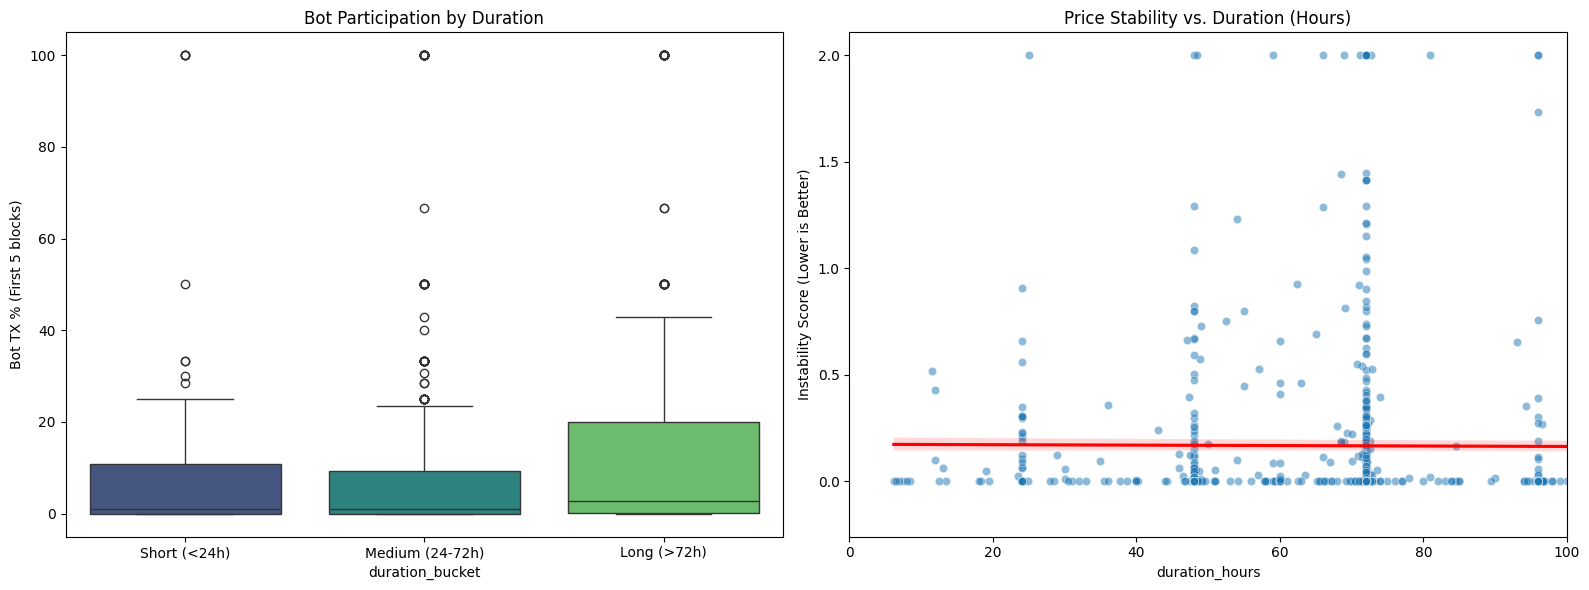

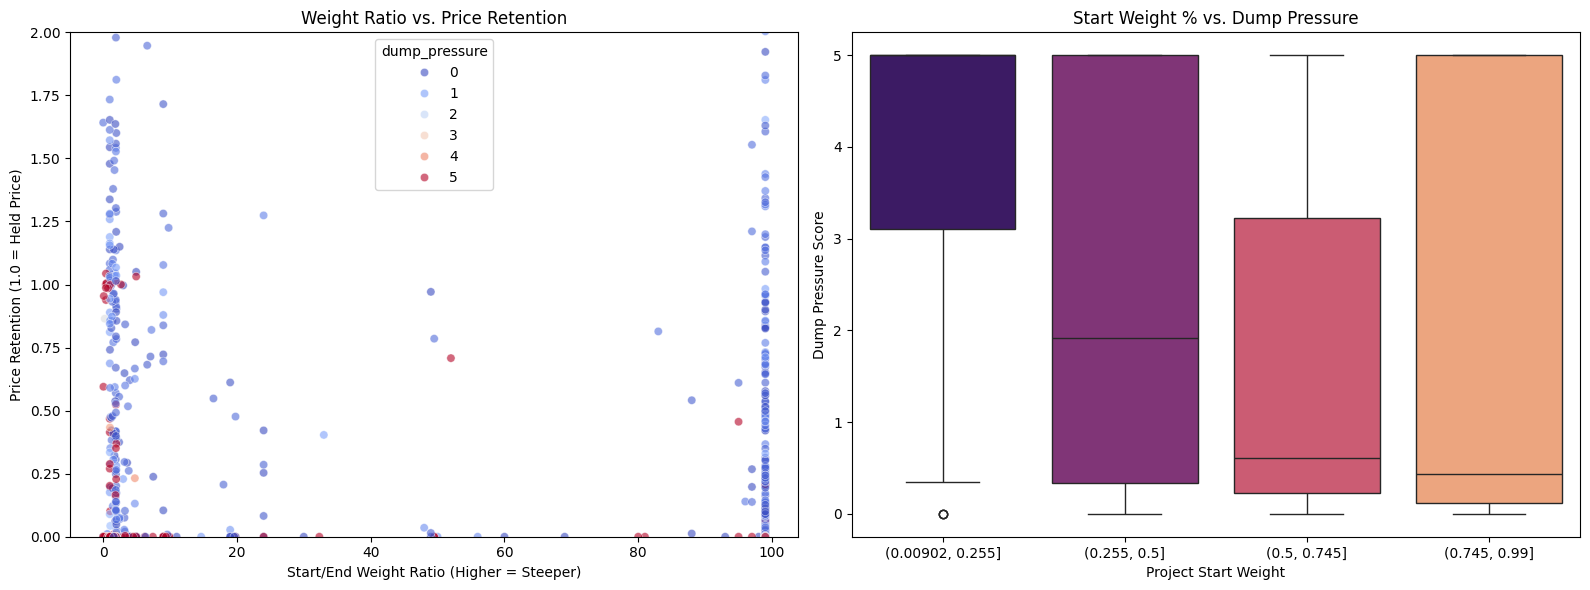

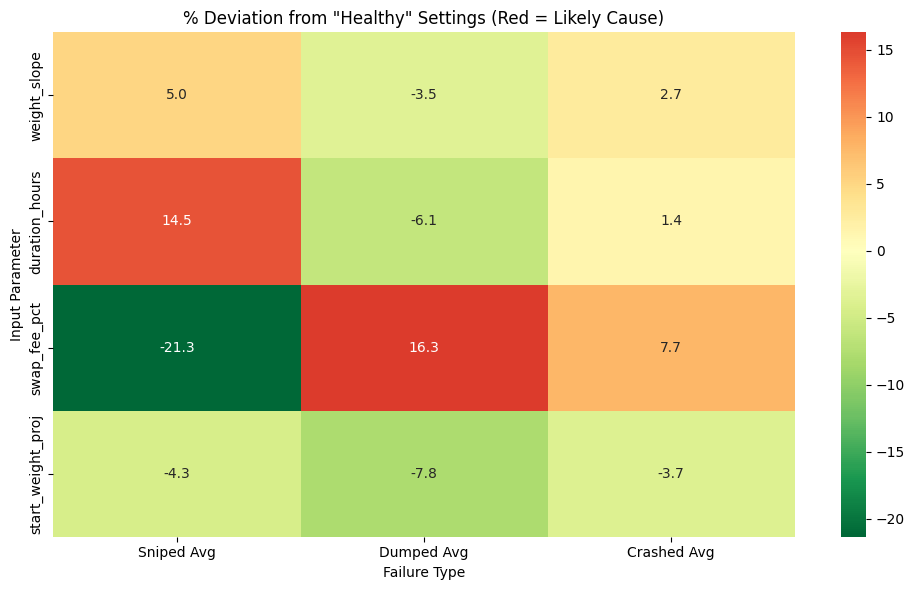

In [8]:
FILE_A = "../media/dune_api_downloads/table_a_final_enriched.csv"  # Source of Table A (Inputs)
FILE_B = "../media/dune_api_downloads/improved_table_b_advanced.csv"   # Source of Table B (Outputs)

def load_and_prep():
    try:
        df_a = pd.read_csv(FILE_A)
        df_b = pd.read_csv(FILE_B)
        df = pd.merge(df_a, df_b, on='pool_address', how='inner')
        
        # --- Feature Engineering for Analysis ---
        # 1. Weight Ratio (How "steep" is the theoretical price drop?)
        # Avoid div by zero
        df['weight_ratio'] = df['start_weight_proj'] / df['end_weight_proj'].replace(0, 0.01)
        
        # 2. Cleanup & Clipping (To remove extreme outliers for clearer graphs)
        df['dump_pressure'] = df['dump_pressure'].clip(upper=5.0)
        df['bot_tx_ratio_pct'] = df['bot_tx_ratio'] * 100
        df['price_discovery_stability'] = df['price_discovery_stability'].clip(upper=2.0)
        
        return df
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return None

# ==============================================================================
# 2. ANALYSIS 1: DURATION IMPACT
# ==============================================================================
def analyze_duration(df):
    print("\n📊 ANALYSIS 1: DURATION IMPACT")
    print("-" * 60)
    
    # Binning Duration for clearer comparison
    # Short (<24h), Medium (24-72h), Long (>72h)
    bins = [0, 24, 72, 1000]
    labels = ['Short (<24h)', 'Medium (24-72h)', 'Long (>72h)']
    df['duration_bucket'] = pd.cut(df['duration_hours'], bins=bins, labels=labels)
    
    # Stats
    stats = df.groupby('duration_bucket')[['price_discovery_stability', 'bot_tx_ratio_pct']].mean()
    print(stats)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot A: Bots vs Duration
    sns.boxplot(data=df, x='duration_bucket', y='bot_tx_ratio_pct', ax=axes[0], palette='viridis')
    axes[0].set_title('Bot Participation by Duration')
    axes[0].set_ylabel('Bot TX % (First 5 blocks)')
    
    # Plot B: Price Discovery vs Duration
    sns.scatterplot(data=df, x='duration_hours', y='price_discovery_stability', alpha=0.5, ax=axes[1])
    # Add trend line
    sns.regplot(data=df, x='duration_hours', y='price_discovery_stability', scatter=False, ax=axes[1], color='red')
    axes[1].set_title('Price Stability vs. Duration (Hours)')
    axes[1].set_ylabel('Instability Score (Lower is Better)')
    axes[1].set_xlim(0, 100) # Zoom in on common durations
    
    plt.tight_layout()

# ==============================================================================
# 3. ANALYSIS 2: STARTING WEIGHTS & RATIOS
# ==============================================================================
def analyze_weights(df):
    print("\n📊 ANALYSIS 2: STARTING WEIGHT RATIOS")
    print("-" * 60)
    
    # Correlation Check
    corr_retention = df['weight_ratio'].corr(df['price_retention'])
    corr_dump = df['weight_ratio'].corr(df['dump_pressure'])
    
    print(f"Correlation (Start/End Ratio vs Price Retention): {corr_retention:.3f}")
    print(f"Correlation (Start/End Ratio vs Dump Pressure):   {corr_dump:.3f}")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot A: Ratio vs Retention (The "Premium" Check)
    # Does a high ratio (e.g., 99/1 -> 50/50) result in price holding?
    sns.scatterplot(data=df, x='weight_ratio', y='price_retention', hue='dump_pressure', palette='coolwarm', alpha=0.6, ax=axes[0])
    axes[0].set_title('Weight Ratio vs. Price Retention')
    axes[0].set_xlabel('Start/End Weight Ratio (Higher = Steeper)')
    axes[0].set_ylabel('Price Retention (1.0 = Held Price)')
    axes[0].set_ylim(0, 2.0)
    
    # Plot B: Start Weight vs Initial Dump
    sns.boxplot(data=df, x=pd.cut(df['start_weight_proj'], 4), y='dump_pressure', ax=axes[1], palette='magma')
    axes[1].set_title('Start Weight % vs. Dump Pressure')
    axes[1].set_xlabel('Project Start Weight')
    axes[1].set_ylabel('Dump Pressure Score')
    
    plt.tight_layout()

# ==============================================================================
# 4. ANALYSIS 3: FAILURE METRICS (FORENSICS)
# ==============================================================================
def analyze_failures(df):
    print("\n📊 ANALYSIS 3: FAILURE FORENSICS (WHAT WENT WRONG?)")
    print("-" * 60)
    
    # Define Failure LBP groups (Top 15% worst performers)
    threshold_bot = df['bot_tx_ratio'].quantile(0.85)
    threshold_dump = df['dump_pressure'].quantile(0.85)
    threshold_crash = 0.2 # Retention < 0.2 (80% drop)
    
    sniped = df[df['bot_tx_ratio'] >= threshold_bot]
    dumped = df[df['dump_pressure'] >= threshold_dump]
    crashed = df[df['price_retention'] <= threshold_crash]
    healthy = df[ (df['bot_tx_ratio'] < threshold_bot) & (df['dump_pressure'] < threshold_dump) ]
    
    print(f"LBP group Sizes -> Sniped: {len(sniped)} | Dumped: {len(dumped)} | Crashed: {len(crashed)} | Healthy: {len(healthy)}")
    
    # Compare Inputs: What did they do differently?
    # We look at Slope, Duration, and Swap Fee
    metrics_to_compare = ['weight_slope', 'duration_hours', 'swap_fee_pct', 'start_weight_proj']
    
    summary = pd.DataFrame({
        'Healthy Avg': healthy[metrics_to_compare].mean(),
        'Sniped Avg': sniped[metrics_to_compare].mean(),
        'Dumped Avg': dumped[metrics_to_compare].mean(),
        'Crashed Avg': crashed[metrics_to_compare].mean()
    })
    
    print("\nForensic Report (Average Input Settings):")
    print(summary)
    
    # Visualization: Heatmap of Deviation
    # Show % difference from Healthy average
    deviation = ((summary.drop('Healthy Avg', axis=1).sub(summary['Healthy Avg'], axis=0)).div(summary['Healthy Avg'], axis=0)) * 100
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(deviation, annot=True, fmt=".1f", cmap="RdYlGn_r", center=0)
    plt.title('% Deviation from "Healthy" Settings (Red = Likely Cause)')
    plt.ylabel('Input Parameter')
    plt.xlabel('Failure Type')
    
    plt.tight_layout()

# ==============================================================================
# MAIN
# ==============================================================================
if __name__ == "__main__":
    df = load_and_prep()
    if df is not None:
        analyze_duration(df)
        analyze_weights(df)
        analyze_failures(df)
        print("\n🚀 Done! Please copy the output text above and check the 3 PNG files.")


Generating Graph 1: Duration 'U-Curve'...
Generating Graph 2: Weight Ratio Placebo...
Generating Graph 3: Failure Forensics...


C:\Users\kaiqu\AppData\Local\Temp\ipykernel_21172\1646833383.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='duration_bucket', y='bot_tx_ratio_pct', palette="viridis", alpha=0.6, errorbar=None)
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_21172\1646833383.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='LBP group', y='start_weight_proj', ax=axes[0], palette=['#2ecc71', '#e74c3c', '#f39c12'], order=['Healthy', 'Dumped (>85th %)', 'Sniped (>85th %)'])
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_21172\1646833383.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue`


🚀 All graphs generated successfully.


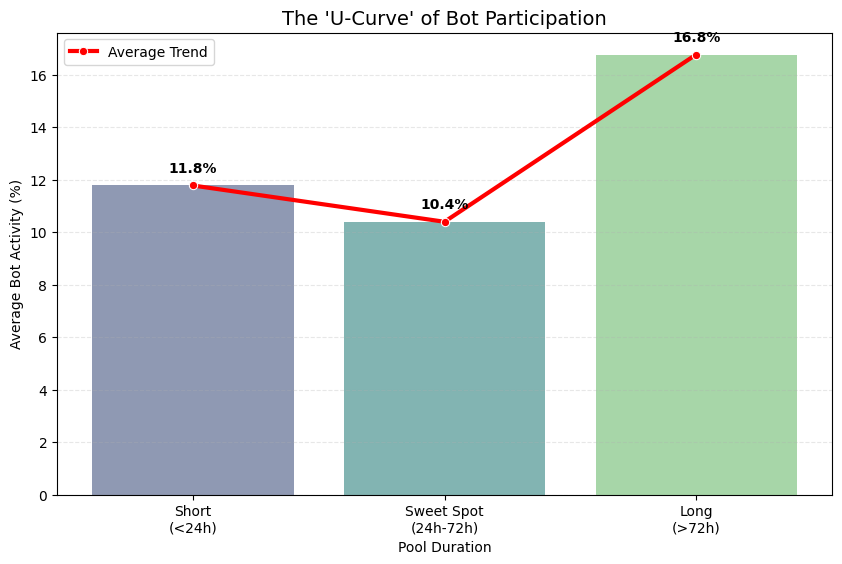

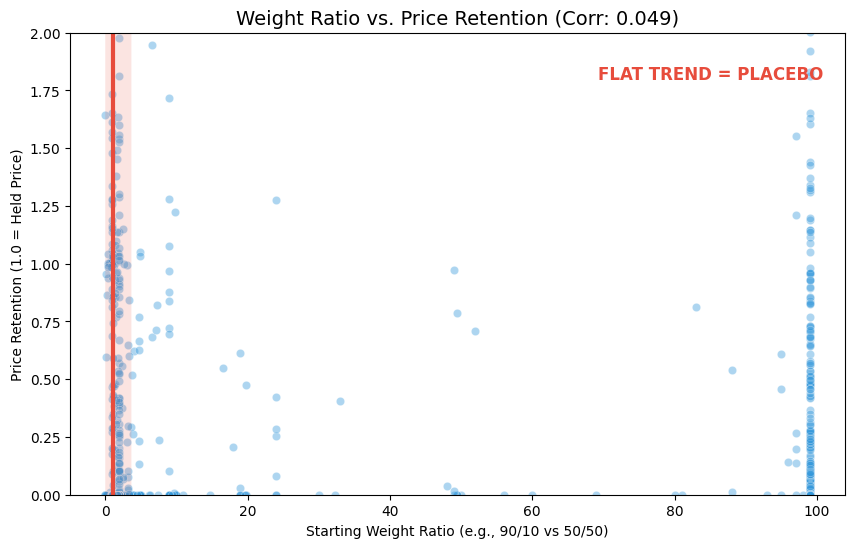

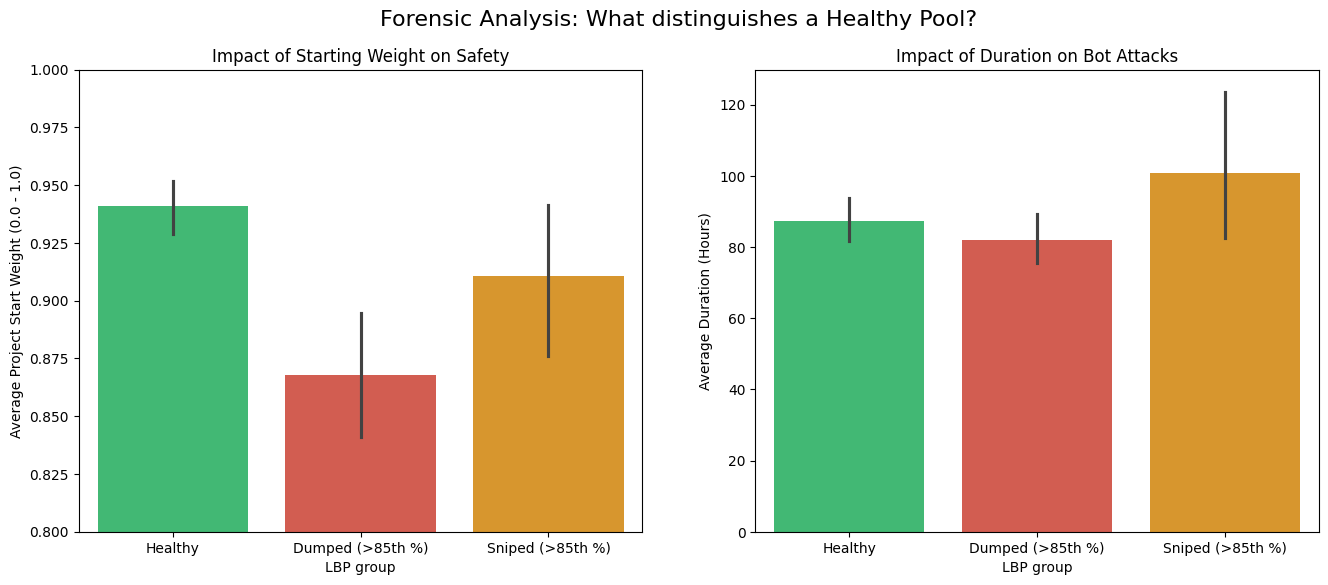

In [7]:
def load_data():
    try:
        df_a = pd.read_csv(FILE_A)
        df_b = pd.read_csv(FILE_B)
        df = pd.merge(df_a, df_b, on='pool_address', how='inner')
        
        # Feature Engineering
        df['weight_ratio'] = df['start_weight_proj'] / df['end_weight_proj'].replace(0, 0.01)
        df['bot_tx_ratio_pct'] = df['bot_tx_ratio'] * 100
        df['dump_pressure'] = df['dump_pressure'].clip(upper=5.0) # Clip for cleaner graphs
        
        return df
    except Exception as e:
        print(f"❌ Error: {e}")
        return None

# ==============================================================================
# 2. GENERATE "U-CURVE" (DURATION)
# ==============================================================================
def plot_u_curve(df):
    print("\nGenerating Graph 1: Duration 'U-Curve'...")
    
    # Bucketize
    bins = [0, 24, 72, 1000]
    labels = ['Short\n(<24h)', 'Sweet Spot\n(24h-72h)', 'Long\n(>72h)']
    df['duration_bucket'] = pd.cut(df['duration_hours'], bins=bins, labels=labels)
    
    # Calculate Means for the Line Plot
    grouped = df.groupby('duration_bucket', observed=True)['bot_tx_ratio_pct'].mean().reset_index()
    
    plt.figure(figsize=(10, 6))
    
    # Bar Plot for the "Mass"
    sns.barplot(data=df, x='duration_bucket', y='bot_tx_ratio_pct', palette="viridis", alpha=0.6, errorbar=None)
    
    # Line Plot to emphasize the "U" Shape
    sns.lineplot(data=grouped, x='duration_bucket', y='bot_tx_ratio_pct', marker='o', color='red', linewidth=3, label='Average Trend')
    
    # Annotate values
    for index, row in grouped.iterrows():
        plt.text(index, row.bot_tx_ratio_pct + 0.5, f"{row.bot_tx_ratio_pct:.1f}%", 
                 color='black', ha="center", fontweight='bold')

    plt.title("The 'U-Curve' of Bot Participation", fontsize=14)
    plt.ylabel("Average Bot Activity (%)")
    plt.xlabel("Pool Duration")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    

# ==============================================================================
# 3. GENERATE "PLACEBO EFFECT" (WEIGHTS)
# ==============================================================================
def plot_weight_placebo(df):
    print("Generating Graph 2: Weight Ratio Placebo...")
    
    correlation = df['weight_ratio'].corr(df['price_retention'])
    
    plt.figure(figsize=(10, 6))
    
    # Scatter Plot
    sns.scatterplot(data=df, x='weight_ratio', y='price_retention', alpha=0.4, color='#3498db')
    
    # Trend Line (The visual proof of "Flatness")
    sns.regplot(data=df, x='weight_ratio', y='price_retention', scatter=False, color='#e74c3c', line_kws={"linewidth": 3})
    
    plt.title(f"Weight Ratio vs. Price Retention (Corr: {correlation:.3f})", fontsize=14)
    plt.xlabel("Starting Weight Ratio (e.g., 90/10 vs 50/50)")
    plt.ylabel("Price Retention (1.0 = Held Price)")
    plt.ylim(0, 2.0) # Focus on the relevant range
    
    # Annotation
    plt.text(df['weight_ratio'].max()*0.7, 1.8, "FLAT TREND = PLACEBO", 
             fontsize=12, color='#e74c3c', fontweight='bold')
    

# ==============================================================================
# 4. GENERATE "FORENSIC COMPARISON" (FAILURES)
# ==============================================================================
def plot_failure_forensics(df):
    print("Generating Graph 3: Failure Forensics...")
    
    # Define LBP groups
    threshold_dump = df['dump_pressure'].quantile(0.85)
    threshold_bot = df['bot_tx_ratio'].quantile(0.85)
    
    # Create Labels
    conditions = [
        (df['dump_pressure'] >= threshold_dump),
        (df['bot_tx_ratio'] >= threshold_bot),
        (df['dump_pressure'] < threshold_dump) & (df['bot_tx_ratio'] < threshold_bot)
    ]
    choices = ['Dumped (>85th %)', 'Sniped (>85th %)', 'Healthy']
    df['LBP group'] = np.select(conditions, choices, default='Other')
    
    # Filter only relevant LBP groups
    plot_df = df[df['LBP group'].isin(['Healthy', 'Dumped (>85th %)', 'Sniped (>85th %)'])].copy()
    
    # Prepare Data for Side-by-Side Plotting
    # We want to show Start Weight (Dump Cause) and Duration (Snipe Cause)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Start Weight Comparison
    sns.barplot(data=plot_df, x='LBP group', y='start_weight_proj', ax=axes[0], palette=['#2ecc71', '#e74c3c', '#f39c12'], order=['Healthy', 'Dumped (>85th %)', 'Sniped (>85th %)'])
    axes[0].set_title("Impact of Starting Weight on Safety")
    axes[0].set_ylabel("Average Project Start Weight (0.0 - 1.0)")
    axes[0].set_ylim(0.8, 1.0) # Zoom in to show the difference (94% vs 86%)
    
    # 2. Duration Comparison
    sns.barplot(data=plot_df, x='LBP group', y='duration_hours', ax=axes[1], palette=['#2ecc71', '#e74c3c', '#f39c12'], order=['Healthy', 'Dumped (>85th %)', 'Sniped (>85th %)'])
    axes[1].set_title("Impact of Duration on Bot Attacks")
    axes[1].set_ylabel("Average Duration (Hours)")
    
    plt.suptitle("Forensic Analysis: What distinguishes a Healthy Pool?", fontsize=16)

if __name__ == "__main__":
    df = load_data()
    if df is not None:
        plot_u_curve(df)
        plot_weight_placebo(df)
        plot_failure_forensics(df)
        print("\n🚀 All graphs generated successfully.")